In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [4]:
# 1. 데이터 불러오기

iris = load_iris()

data = iris.data
feature_names = iris.feature_names

# 데이터 상위 5개 개체
print(data[:5])
# 특성 (변수) 이
print(feature_names)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
# 2. K-평균에 사용할 변수 선택하기
# 모든 행 중에서 2번 3번 열만 가져오는 슬라이싱
selected_data = data[:, 2:4]

print(selected_data[:5])

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]


In [14]:
# 3. k값에 따른 inertia 확인하기

inertia = []
for k in range(1, 7):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(selected_data)
  inertia.append(km.inertia_)

print(km.inertia_)

11.443249546749545


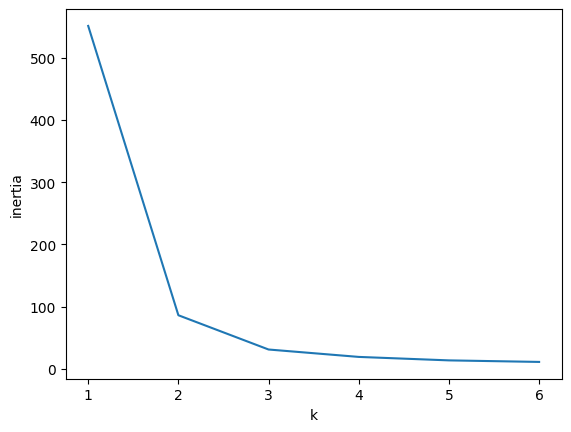

In [15]:
# 4. 엘보우 매서드 그래프 그리기

plt.plot(range(1, 7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

In [16]:
# 5. 그래프를 보고 적절한 k값 선택하기 - 6. 적절한 k값=3으로 K-평균 알고리즘 수행하기

best_k = 3
# 그래프가 k=3 부터 완만해

km = KMeans(n_clusters=best_k, random_state=42)
km.fit(selected_data)

labels = km.labels_
print(labels[:10])


[1 1 1 1 1 1 1 1 1 1]


In [17]:
# 7. 군집별 데이터 개수 확인하기

counts = np.bincount(labels)

for cluster_num, count in enumerate(counts):
  print(counts)

[48 50 52]
[48 50 52]
[48 50 52]


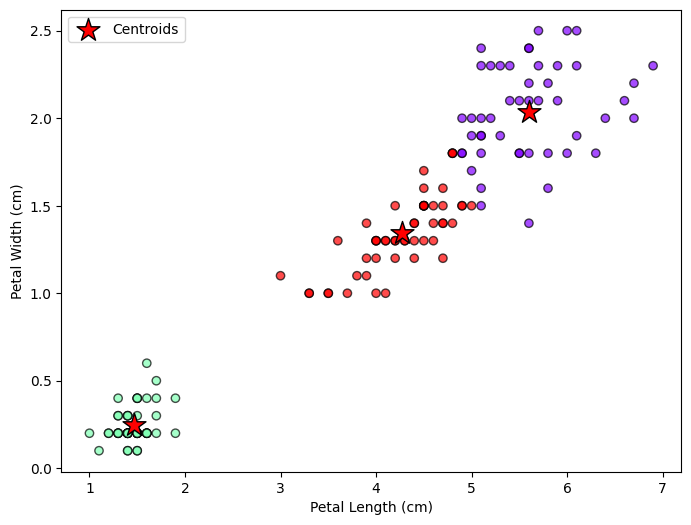

In [19]:
# 8. 군집 결과 시각화하기

plt.figure(figsize=(8, 6))
plt.scatter(selected_data[:, 0], selected_data[:, 1], c=labels, cmap='rainbow', alpha=0.7, edgecolors='k')

centroids = km.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=300, c='red', edgecolors='black', label='Centroids')

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.show()